In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


Active 2013: 4
Active 2014: 5
Split edges drawn: 2


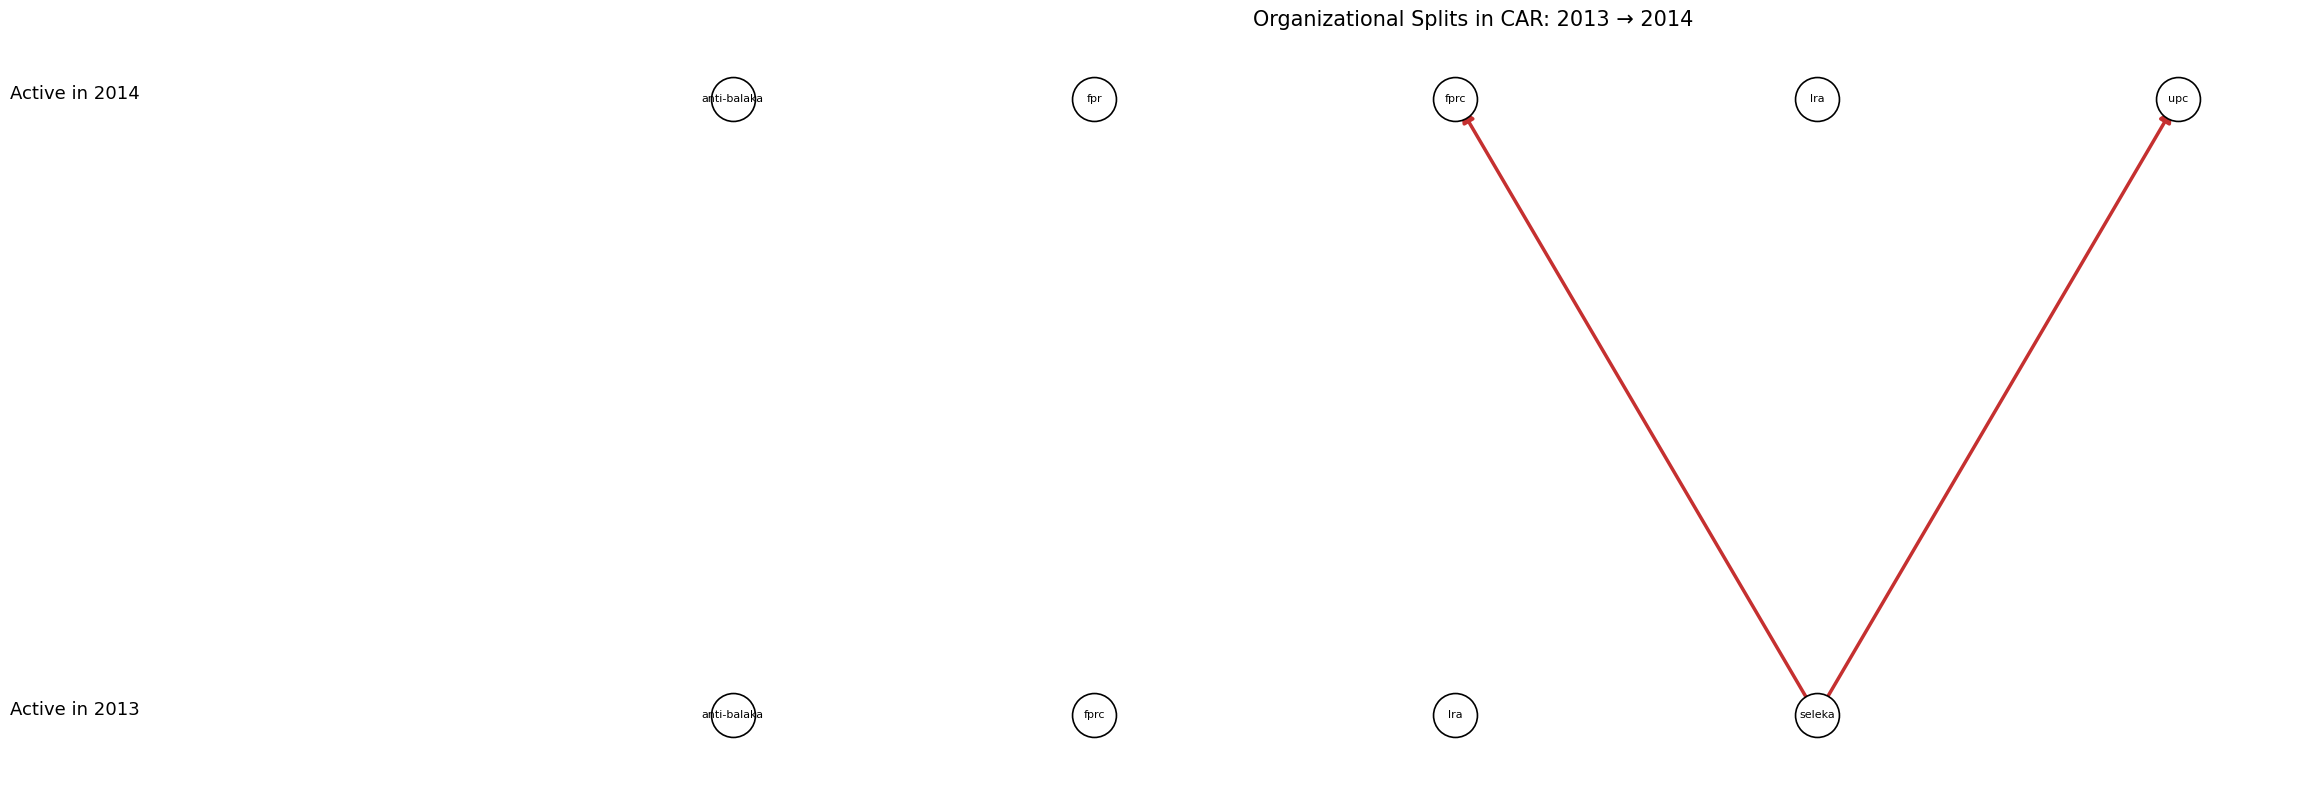

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv"
)

actors = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv"
)

# ---------------------------------------------------
# CLEAN STRINGS (VERY IMPORTANT)
# ---------------------------------------------------
dyads['group_A'] = dyads['group_A'].str.strip().str.lower()
dyads['group_B'] = dyads['group_B'].str.strip().str.lower()
actors['actor'] = actors['actor'].str.strip().str.lower()

# ---------------------------------------------------
# DATE PREPARATION
# ---------------------------------------------------
dyads['split_month'] = pd.to_datetime(dyads['split_month'])
dyads['split_year'] = dyads['split_month'].dt.year

actors['st'] = pd.to_datetime(actors['st'])
actors['ed'] = pd.to_datetime(actors['ed'])
actors['start_year'] = actors['st'].dt.year
actors['end_year'] = actors['ed'].dt.year

# ---------------------------------------------------
# DEFINE YEARS
# ---------------------------------------------------
year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS FUNCTION
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[
        (df['start_year'] <= year) &
        (df['end_year'] >= year)
    ]

df_2013 = active_actors_year(actors, year_1)
df_2014 = active_actors_year(actors, year_2)

groups_2013 = sorted(df_2013['actor'].unique())
groups_2014 = sorted(df_2014['actor'].unique())

print("Active 2013:", len(groups_2013))
print("Active 2014:", len(groups_2014))

# ---------------------------------------------------
# BUILD GRAPH
# ---------------------------------------------------
G = nx.DiGraph()

# Add all active groups
for g in groups_2013:
    G.add_node((g, year_1))

for g in groups_2014:
    G.add_node((g, year_2))

# ---------------------------------------------------
# ADD SPLIT EDGES (parent → child in 2014)
# ---------------------------------------------------
splits_2014 = dyads[
    (dyads['split'] == 1) &
    (dyads['split_year'] == year_2)
]

for _, row in splits_2014.iterrows():
    parent = row['group_A']
    child = row['group_B']

    if parent in groups_2013 and child in groups_2014:
        G.add_edge((parent, year_1), (child, year_2))

print("Split edges drawn:", len(G.edges()))

# ---------------------------------------------------
# POSITIONING
# ---------------------------------------------------
pos = {}

# Spread evenly horizontally
for i, g in enumerate(groups_2013):
    pos[(g, year_1)] = (i, 0)

for i, g in enumerate(groups_2014):
    pos[(g, year_2)] = (i, 1)

# ---------------------------------------------------
# DRAW
# ---------------------------------------------------
plt.figure(figsize=(24, 8))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=1000,
    node_color="white",
    edgecolors="black",
    linewidths=1.2
)

# Split edges
nx.draw_networkx_edges(
    G, pos,
    edge_color="#c53030",
    width=2.5,
    arrows=True,
    arrowsize=18
)

# Labels
labels = {node: node[0] for node in G.nodes()}
nx.draw_networkx_labels(
    G, pos,
    labels,
    font_size=8
)

# Layer labels
plt.text(-2, 0, "Active in 2013", fontsize=13)
plt.text(-2, 1, "Active in 2014", fontsize=13)

plt.title(
    "Organizational Splits in CAR: 2013 → 2014",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()
plt.show()


/var/folders/s7/6y7yz0_j7xn3kp6mnx_nltzr0000gn/T/ipykernel_47584/1575785264.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


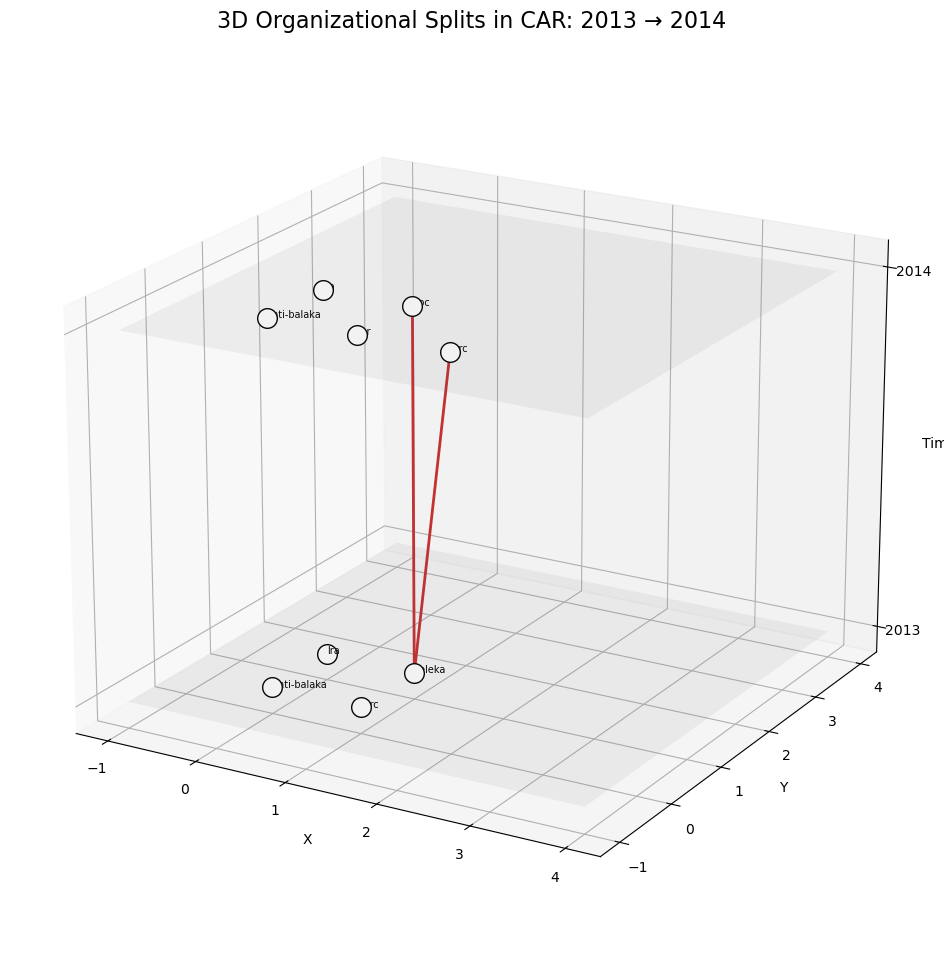

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv"
)

actors = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv"
)

# Clean strings
dyads['group_A'] = dyads['group_A'].str.strip().str.lower()
dyads['group_B'] = dyads['group_B'].str.strip().str.lower()
actors['actor'] = actors['actor'].str.strip().str.lower()

# Dates
dyads['split_month'] = pd.to_datetime(dyads['split_month'])
dyads['split_year'] = dyads['split_month'].dt.year

actors['st'] = pd.to_datetime(actors['st'])
actors['ed'] = pd.to_datetime(actors['ed'])
actors['start_year'] = actors['st'].dt.year
actors['end_year'] = actors['ed'].dt.year

# ---------------------------------------------------
# DEFINE YEARS
# ---------------------------------------------------
year_1 = 2013
year_2 = 2014

def active_actors_year(df, year):
    return df[
        (df['start_year'] <= year) &
        (df['end_year'] >= year)
    ]

groups_2013 = sorted(active_actors_year(actors, year_1)['actor'].unique())
groups_2014 = sorted(active_actors_year(actors, year_2)['actor'].unique())

splits_2014 = dyads[
    (dyads['split'] == 1) &
    (dyads['split_year'] == year_2)
]

# ---------------------------------------------------
# POSITION ACTORS IN 2D GRID
# ---------------------------------------------------
def grid_layout(groups):
    n = len(groups)
    cols = int(np.ceil(np.sqrt(n)))
    positions = {}
    for i, g in enumerate(groups):
        row = i // cols
        col = i % cols
        positions[g] = (col, row)
    return positions

pos_2013 = grid_layout(groups_2013)
pos_2014 = grid_layout(groups_2014)

# ---------------------------------------------------
# 3D PLOT
# ---------------------------------------------------
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

z1 = 0
z2 = 5

# --- Plot layer planes ---
max_range = max(
    max([p[0] for p in pos_2013.values()] + [0]),
    max([p[0] for p in pos_2014.values()] + [0])
) + 2

x_plane = np.linspace(-1, max_range, 10)
y_plane = np.linspace(-1, max_range, 10)
X, Y = np.meshgrid(x_plane, y_plane)

ax.plot_surface(X, Y, np.full_like(X, z1), alpha=0.08, color='gray')
ax.plot_surface(X, Y, np.full_like(X, z2), alpha=0.08, color='gray')

# --- Plot 2013 actors ---
for g, (x, y) in pos_2013.items():
    ax.scatter(x, y, z1, s=200, color="white", edgecolor="black")
    ax.text(x, y, z1, g, fontsize=7)

# --- Plot 2014 actors ---
for g, (x, y) in pos_2014.items():
    ax.scatter(x, y, z2, s=200, color="white", edgecolor="black")
    ax.text(x, y, z2, g, fontsize=7)

# --- Plot split edges (parent → child) ---
for _, row in splits_2014.iterrows():
    parent = row['group_A']
    child = row['group_B']

    if parent in pos_2013 and child in pos_2014:
        x1, y1 = pos_2013[parent]
        x2, y2 = pos_2014[child]

        ax.plot(
            [x1, x2],
            [y1, y2],
            [z1, z2],
            color="#c53030",
            linewidth=2
        )

# --- Formatting ---
ax.set_title("3D Organizational Splits in CAR: 2013 → 2014", fontsize=16)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Time")

ax.set_zticks([z1, z2])
ax.set_zticklabels([str(year_1), str(year_2)])

ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()


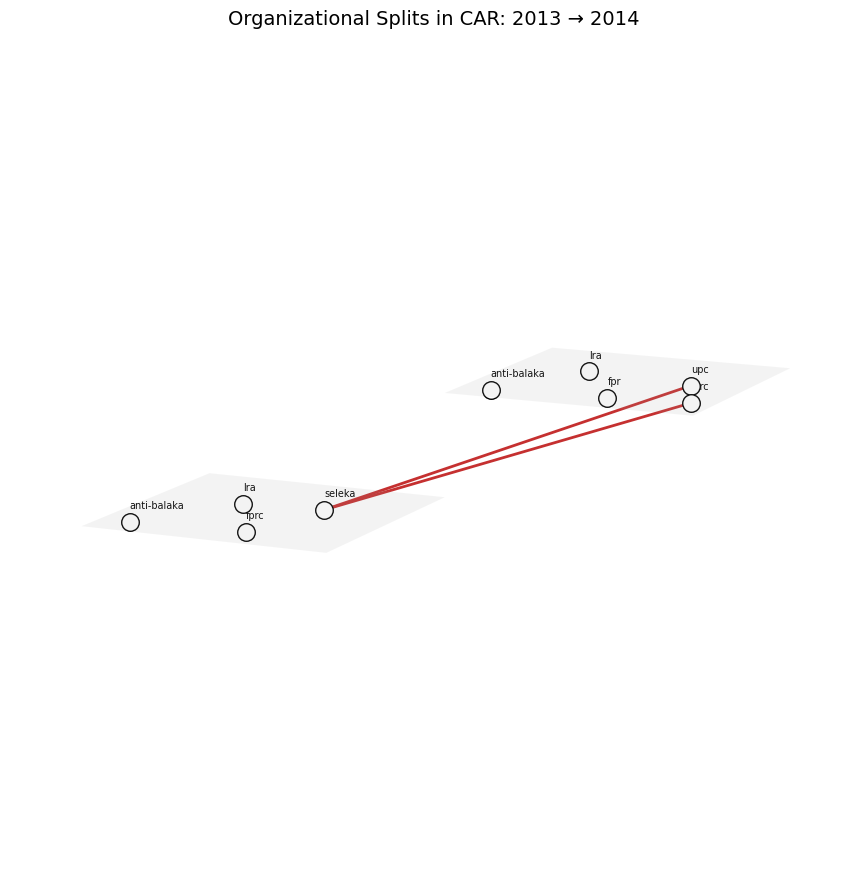

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv"
)

actors = pd.read_csv(
    "/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv"
)

# Clean
dyads['group_A'] = dyads['group_A'].str.strip().str.lower()
dyads['group_B'] = dyads['group_B'].str.strip().str.lower()
actors['actor'] = actors['actor'].str.strip().str.lower()

# Dates
dyads['split_month'] = pd.to_datetime(dyads['split_month'])
dyads['split_year'] = dyads['split_month'].dt.year

actors['st'] = pd.to_datetime(actors['st'])
actors['ed'] = pd.to_datetime(actors['ed'])
actors['start_year'] = actors['st'].dt.year
actors['end_year'] = actors['ed'].dt.year

year_1 = 2013
year_2 = 2014

def active_actors_year(df, year):
    return df[
        (df['start_year'] <= year) &
        (df['end_year'] >= year)
    ]

groups_2013 = sorted(active_actors_year(actors, year_1)['actor'].unique())
groups_2014 = sorted(active_actors_year(actors, year_2)['actor'].unique())

splits_2014 = dyads[
    (dyads['split'] == 1) &
    (dyads['split_year'] == year_2)
]

# ---------------------------------------------------
# GRID LAYOUT
# ---------------------------------------------------
def scattered_grid_layout(groups, spacing=1.8, jitter=0.35):
    positions = {}
    n = len(groups)
    cols = int(np.ceil(np.sqrt(n)))

    for i, g in enumerate(groups):
        row = i // cols
        col = i % cols

        # Base grid
        x = col * spacing
        y = row * spacing

        # Offset every other row (hex-style feel)
        if row % 2 == 1:
            x += spacing / 2

        # Deterministic jitter (based on index)
        dx = ((i * 7) % 10 - 5) / 5 * jitter
        dy = ((i * 13) % 10 - 5) / 5 * jitter

        positions[g] = (x + dx, y + dy)

    return positions


# Apply layout
pos_2013 = scattered_grid_layout(groups_2013)
pos_2014 = scattered_grid_layout(groups_2014)

# ---------------------------------------------------
# 3D FIGURE
# ---------------------------------------------------
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Platform geometry
# Platform height (closer together)
z1 = 0
z2 = 0.4   # was 2.0 — now much closer
# Horizontal shift (slightly larger to compensate)
x_shift = 5.0
y_shift = 5.0

# --- Create square platform for 2013 (bottom-left) ---
size = max(len(pos_2013), len(pos_2014))
plane_size = int(np.ceil(np.sqrt(size))) + 1

X1, Y1 = np.meshgrid(
    np.linspace(-1, plane_size, 2),
    np.linspace(-1, plane_size, 2)
)

ax.plot_surface(
    X1, Y1,
    np.full_like(X1, z1),
    color='lightgray',
    alpha=0.12
)

# --- Create square platform for 2014 (top-right) ---
X2 = X1 + x_shift
Y2 = Y1 + y_shift

ax.plot_surface(
    X2, Y2,
    np.full_like(X2, z2),
    color='lightgray',
    alpha=0.12
)

# ---------------------------------------------------
# Plot actors
# ---------------------------------------------------
for g, (x, y) in pos_2013.items():
    ax.scatter(x, y, z1, s=160, color="white", edgecolor="black")
    ax.text(x, y, z1 + 0.05, g, fontsize=7)

for g, (x, y) in pos_2014.items():
    ax.scatter(x + x_shift, y + y_shift, z2, s=160,
               color="white", edgecolor="black")
    ax.text(x + x_shift, y + y_shift, z2 + 0.05, g, fontsize=7)

# ---------------------------------------------------
# Plot split links
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row['group_A']
    child = row['group_B']

    if parent in pos_2013 and child in pos_2014:
        x1, y1 = pos_2013[parent]
        x2, y2 = pos_2014[child]

        ax.plot(
            [x1, x2 + x_shift],
            [y1, y2 + y_shift],
            [z1, z2],
            color="#c53030",
            linewidth=2
        )

# ---------------------------------------------------
# CLEAN LOOK (remove axes entirely)
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=12, azim=-65)
ax.set_box_aspect([1,1,0.2]) 
plt.title("Organizational Splits in CAR: 2013 → 2014", fontsize=14)
plt.tight_layout()
plt.show()


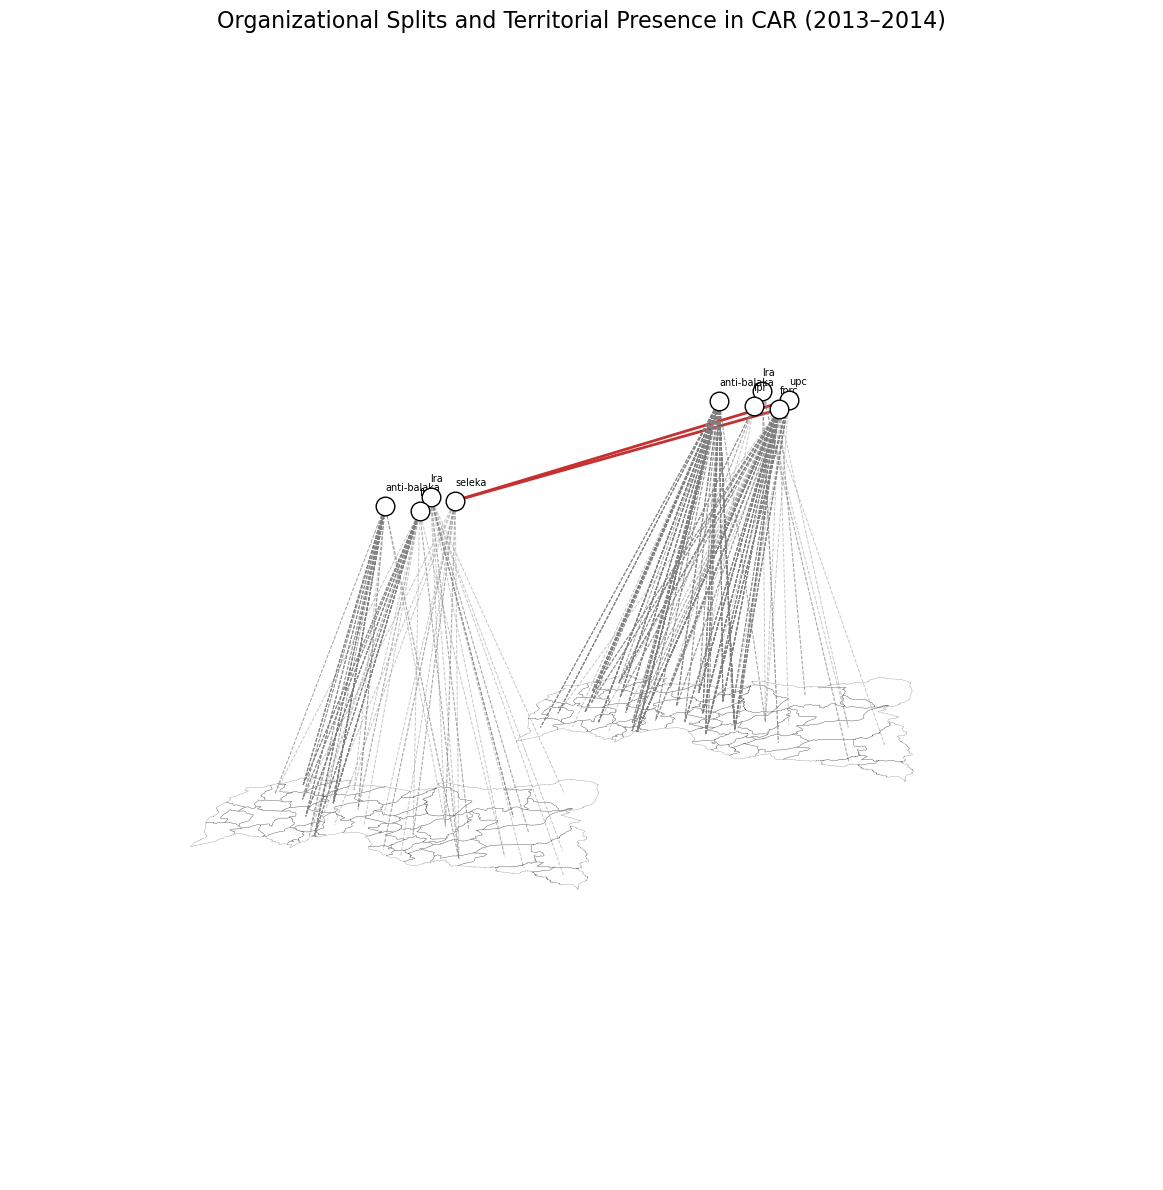

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")
actors = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv")
gadm = gpd.read_file("/Users/samqiu/Desktop/triad_datacollecting-main/car_adm2.shp")

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
dyads["group_A"] = dyads["group_A"].astype(str).str.strip().str.lower()
dyads["group_B"] = dyads["group_B"].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()

gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

# Dates
dyads["split_month"] = pd.to_datetime(dyads["split_month"])
dyads["split_year"] = dyads["split_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"])
actors["ed"] = pd.to_datetime(actors["ed"])
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

df13 = active_actors_year(actors, year_1)
df14 = active_actors_year(actors, year_2)

groups_2013 = sorted(df13["actor"].unique())
groups_2014 = sorted(df14["actor"].unique())

splits_2014 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()

# ---------------------------------------------------
# SCATTERED GRID LAYOUT
# ---------------------------------------------------
def scattered_grid_layout(groups, spacing=2.0, jitter=0.4):
    positions = {}
    n = len(groups)
    cols = int(np.ceil(np.sqrt(max(n, 1))))

    for i, g in enumerate(groups):
        row = i // cols
        col = i % cols

        x = col * spacing
        y = row * spacing

        if row % 2 == 1:
            x += spacing / 2

        dx = ((i * 7) % 10 - 5) / 5 * jitter
        dy = ((i * 13) % 10 - 5) / 5 * jitter

        positions[g] = (x + dx, y + dy)

    return positions

pos13 = scattered_grid_layout(groups_2013)
pos14 = scattered_grid_layout(groups_2014)

# ---------------------------------------------------
# NORMALIZE MAP TO GRID COORDINATES (critical!)
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom_to_grid(geom, target_width=30.0):
    """
    Rescale/translate geometry so its bounding box fits roughly within [0, target_width] in x,
    keeping aspect ratio.
    """
    width = maxx - minx
    height = maxy - miny
    if width == 0 or height == 0:
        return geom

    scale = target_width / width
    # scale about (minx, miny), then translate so min corner becomes (0,0)
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(lambda g: normalize_geom_to_grid(g, target_width=30.0))

# ---------------------------------------------------
# 3D FIGURE SETUP
# ---------------------------------------------------
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection="3d")

# Platform shifts (keep them separate in x/y)
x_shift = 14.0
y_shift = 14.0

# Z positions (map below each platform)
z_map_2013 = 0.0
z_platform_2013 = 2.0

z_map_2014 = 0.0
z_platform_2014 = 2.0

# Put platform B slightly “above” A if you want visual separation in z:
z_platform_2014 = 2.4
z_map_2014 = 0.4

# ---------------------------------------------------
# PLOT MAPS
# ---------------------------------------------------
def plot_map_layer(gdf, z_level, xoff=0.0, yoff=0.0,
                   color="black", lw=0.25, alpha=0.45):
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue

        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)

        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color=color, linewidth=lw, alpha=alpha)

        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:  # shapely >=2.0
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color=color, linewidth=lw, alpha=alpha)

# Map under platform A
plot_map_layer(gadm, z_map_2013, xoff=0.0, yoff=0.0)

# Map under platform B (shifted in x/y)
plot_map_layer(gadm, z_map_2014, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# PLOT ACTORS (two platforms)
# ---------------------------------------------------
for g, (x, y) in pos13.items():
    ax.scatter(x, y, z_platform_2013, s=180, color="white", edgecolor="black")
    ax.text(x, y, z_platform_2013 + 0.08, g, fontsize=7)

for g, (x, y) in pos14.items():
    ax.scatter(x + x_shift, y + y_shift, z_platform_2014, s=180, color="white", edgecolor="black")
    ax.text(x + x_shift, y + y_shift, z_platform_2014 + 0.08, g, fontsize=7)

# ---------------------------------------------------
# SPLIT LINKS (platform-to-platform)
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row["group_A"]
    child = row["group_B"]

    if parent in pos13 and child in pos14:
        x1, y1 = pos13[parent]
        x2, y2 = pos14[child]

        ax.plot([x1, x2 + x_shift],
                [y1, y2 + y_shift],
                [z_platform_2013, z_platform_2014],
                color="#c53030", linewidth=2)

# ---------------------------------------------------
# ACTOR → LOCATION LINKS (gray dashed)
# ---------------------------------------------------
gadm_name_set = set(gadm["NAME_2"].values)

def location_centroid_xy(location_name, xoff=0.0, yoff=0.0):
    sub = gadm[gadm["NAME_2"] == location_name]
    if sub.empty:
        return None

    geom = sub.geometry.iloc[0]
    if geom is None or geom.is_empty:
        return None

    geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)
    c = geom2.centroid
    return (c.x, c.y)

def link_actor_to_locations(df_year, pos_dict, z_platform, z_map,
                            actor_xoff=0.0, actor_yoff=0.0,
                            map_xoff=0.0, map_yoff=0.0):
    for _, r in df_year.iterrows():
        actor = r["actor"]
        loc = r["NAME_2"]

        if actor not in pos_dict:
            continue
        if loc not in gadm_name_set:
            continue

        xy = location_centroid_xy(loc, xoff=map_xoff, yoff=map_yoff)
        if xy is None:
            continue

        x_map, y_map = xy
        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        ax.plot([x_actor, x_map],
                [y_actor, y_map],
                [z_platform, z_map],
                color="gray",
                linewidth=0.7,
                alpha=0.45,
                linestyle="dashed")

# Platform A: actors -> map A
link_actor_to_locations(df13, pos13, z_platform_2013, z_map_2013,
                        actor_xoff=0.0, actor_yoff=0.0,
                        map_xoff=0.0, map_yoff=0.0)

# Platform B: actors -> map B
link_actor_to_locations(df14, pos14, z_platform_2014, z_map_2014,
                        actor_xoff=x_shift, actor_yoff=y_shift,
                        map_xoff=x_shift, map_yoff=y_shift)

# ---------------------------------------------------
# CLEAN VISUAL
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.7])

plt.title("Organizational Splits and Territorial Presence in CAR (2013–2014)", fontsize=16)
plt.tight_layout()
plt.show()


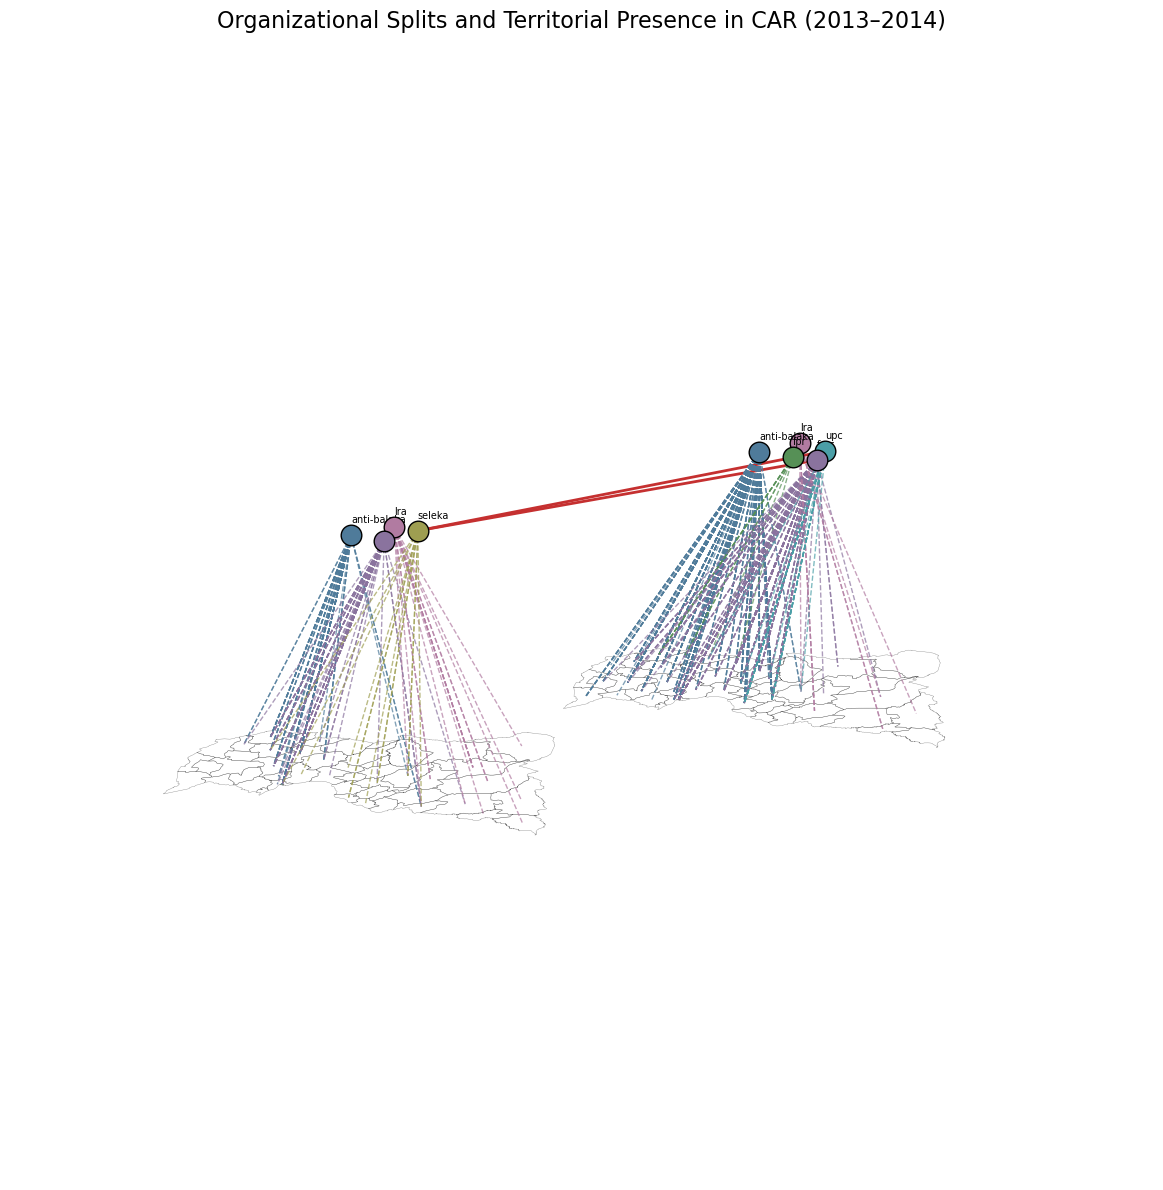

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")
actors = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv")
gadm = gpd.read_file("/Users/samqiu/Desktop/triad_datacollecting-main/car_adm2.shp")

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
dyads["group_A"] = dyads["group_A"].astype(str).str.strip().str.lower()
dyads["group_B"] = dyads["group_B"].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()
gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

# Dates
dyads["split_month"] = pd.to_datetime(dyads["split_month"])
dyads["split_year"] = dyads["split_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"])
actors["ed"] = pd.to_datetime(actors["ed"])
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

df13 = active_actors_year(actors, year_1)
df14 = active_actors_year(actors, year_2)

groups_2013 = sorted(df13["actor"].unique())
groups_2014 = sorted(df14["actor"].unique())
all_groups = sorted(set(groups_2013 + groups_2014))

splits_2014 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()

# ---------------------------------------------------
# SCATTERED GRID LAYOUT
# ---------------------------------------------------
def scattered_grid_layout(groups, spacing=2.0, jitter=0.4):
    positions = {}
    n = len(groups)
    cols = int(np.ceil(np.sqrt(max(n, 1))))

    for i, g in enumerate(groups):
        row = i // cols
        col = i % cols

        x = col * spacing
        y = row * spacing

        if row % 2 == 1:
            x += spacing / 2

        dx = ((i * 7) % 10 - 5) / 5 * jitter
        dy = ((i * 13) % 10 - 5) / 5 * jitter

        positions[g] = (x + dx, y + dy)

    return positions

pos13 = scattered_grid_layout(groups_2013)
pos14 = scattered_grid_layout(groups_2014)

# ---------------------------------------------------
# ACTOR COLOR PALETTE (desaturated)
# ---------------------------------------------------
base_colors = plt.cm.tab10(np.linspace(0, 1, len(all_groups)))

def mix_with_gray(color, gray_level=0.5):
    r, g, b, a = color
    gray = np.array([0.5, 0.5, 0.5])
    rgb = np.array([r, g, b])
    mixed = rgb * (1 - gray_level) + gray * gray_level
    return (*mixed, 1.0)

actor_colors = {
    g: mix_with_gray(base_colors[i], gray_level=0.5)
    for i, g in enumerate(all_groups)
}

# ---------------------------------------------------
# NORMALIZE MAP (larger size)
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom_to_grid(geom, target_width=30.0):
    width = maxx - minx
    if width == 0:
        return geom

    scale = target_width / width
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(
    lambda g: normalize_geom_to_grid(g, target_width=30.0)
)

# ---------------------------------------------------
# 3D FIGURE SETUP
# ---------------------------------------------------
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection="3d")

x_shift = 18.0
y_shift = 18.0

# Reduced vertical distance
z_map_2013 = 0.0
z_platform_2013 = 1.2

z_map_2014 = 0.2
z_platform_2014 = 1.4

# ---------------------------------------------------
# PLOT MAPS
# ---------------------------------------------------
def plot_map_layer(gdf, z_level, xoff=0.0, yoff=0.0):
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue

        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)

        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color="black", linewidth=0.25, alpha=0.5)

        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color="black", linewidth=0.25, alpha=0.5)

plot_map_layer(gadm, z_map_2013)
plot_map_layer(gadm, z_map_2014, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# PLOT ACTORS
# ---------------------------------------------------
for g, (x, y) in pos13.items():
    ax.scatter(x, y, z_platform_2013,
               s=220,
               color=actor_colors[g],
               edgecolor="black")
    ax.text(x, y, z_platform_2013 + 0.05, g, fontsize=7)

for g, (x, y) in pos14.items():
    ax.scatter(x + x_shift, y + y_shift, z_platform_2014,
               s=220,
               color=actor_colors[g],
               edgecolor="black")
    ax.text(x + x_shift, y + y_shift, z_platform_2014 + 0.05, g, fontsize=7)

# ---------------------------------------------------
# SPLIT LINKS (red)
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row["group_A"]
    child = row["group_B"]

    if parent in pos13 and child in pos14:
        x1, y1 = pos13[parent]
        x2, y2 = pos14[child]

        ax.plot([x1, x2 + x_shift],
                [y1, y2 + y_shift],
                [z_platform_2013, z_platform_2014],
                color="#c53030", linewidth=2)

# ---------------------------------------------------
# ACTOR → LOCATION LINKS (colored dashed)
# ---------------------------------------------------
gadm_name_set = set(gadm["NAME_2"].values)

def location_centroid_xy(location_name, xoff=0.0, yoff=0.0):
    sub = gadm[gadm["NAME_2"] == location_name]
    if sub.empty:
        return None
    geom = sub.geometry.iloc[0]
    geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)
    c = geom2.centroid
    return (c.x, c.y)

def link_actor_to_locations(df_year, pos_dict,
                            z_platform, z_map,
                            actor_xoff=0.0, actor_yoff=0.0,
                            map_xoff=0.0, map_yoff=0.0):
    for _, r in df_year.iterrows():
        actor = r["actor"]
        loc = r["NAME_2"]

        if actor not in pos_dict or loc not in gadm_name_set:
            continue

        xy = location_centroid_xy(loc, xoff=map_xoff, yoff=map_yoff)
        if xy is None:
            continue

        x_map, y_map = xy
        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        ax.plot([x_actor, x_map],
                [y_actor, y_map],
                [z_platform, z_map],
                color=actor_colors[actor],
                linewidth=1.0,
                alpha=0.7,
                linestyle="dashed")

link_actor_to_locations(df13, pos13,
                        z_platform_2013, z_map_2013)

link_actor_to_locations(df14, pos14,
                        z_platform_2014, z_map_2014,
                        actor_xoff=x_shift, actor_yoff=y_shift,
                        map_xoff=x_shift, map_yoff=y_shift)

# ---------------------------------------------------
# CLEAN VISUAL
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.5])

plt.title("Organizational Splits and Territorial Presence in CAR (2013–2014)",
          fontsize=16)
plt.tight_layout()
plt.show()


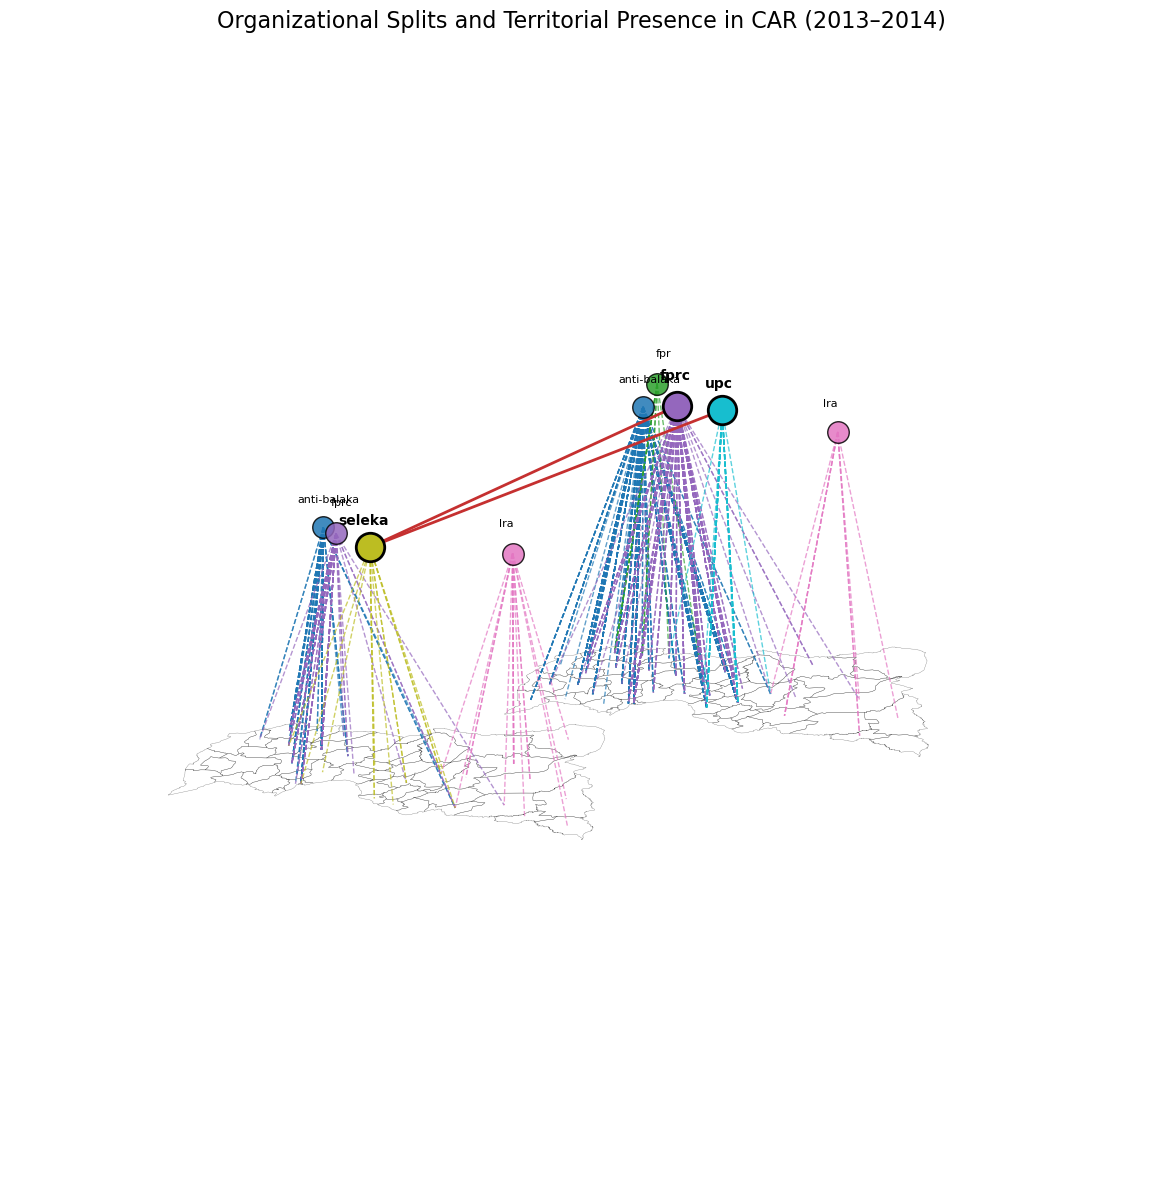

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")
actors = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv")
gadm = gpd.read_file("/Users/samqiu/Desktop/triad_datacollecting-main/car_adm2.shp")

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
for col in ["group_A", "group_B"]:
    dyads[col] = dyads[col].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()
gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

dyads["split_month"] = pd.to_datetime(dyads["split_month"])
dyads["split_year"] = dyads["split_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"])
actors["ed"] = pd.to_datetime(actors["ed"])
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

df13 = active_actors_year(actors, year_1)
df14 = active_actors_year(actors, year_2)

splits_2014 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()

# ---------------------------------------------------
# NORMALIZE MAP
# ---------------------------------------------------
# ---------------------------------------------------
# NORMALIZE MAP GEOMETRY
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom(geom, target_width=40.0):
    width = maxx - minx
    if width == 0:
        return geom

    scale = target_width / width
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(normalize_geom)

# ---------------------------------------------------
# FIX: REPROJECT BEFORE CENTROID CALCULATION
# ---------------------------------------------------
if gadm.crs is not None and gadm.crs.is_geographic:
    gadm_proj = gadm.to_crs(epsg=3857)  # safe projected CRS for visualization
else:
    gadm_proj = gadm.copy()

gadm_proj["centroid"] = gadm_proj.geometry.centroid

# Transform centroids back to original CRS
gadm["centroid"] = (
    gadm_proj.set_geometry("centroid")
             .to_crs(gadm.crs)["centroid"]
)

# ---------------------------------------------------
# COLORS
# ---------------------------------------------------
all_groups = sorted(set(list(pos13.keys()) + list(pos14.keys())))
base_colors = plt.cm.tab10(np.linspace(0, 1, len(all_groups)))
actor_colors = {g: base_colors[i] for i, g in enumerate(all_groups)}

# ---------------------------------------------------
# 3D FIGURE
# ---------------------------------------------------
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection="3d")

z_map_2013 = 0.0
z_platform_2013 = 1
z_map_2014 = 0.2
z_platform_2014 = 1.4

# ---------------------------------------------------
# PLOT MAP
# ---------------------------------------------------
def plot_map_layer(gdf, z_level, xoff=0.0, yoff=0.0):
    for geom in gdf.geometry:
        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)

        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color="black", linewidth=0.25, alpha=0.5)

        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color="black", linewidth=0.25, alpha=0.5)

plot_map_layer(gadm, z_map_2013)
plot_map_layer(gadm, z_map_2014, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# PLOT ACTORS
# ---------------------------------------------------
highlight_2013 = {"seleka"}
highlight_2014 = {"fprc", "upc"}


def radial_offsets(n, radius=0.45):
    """Generate evenly spaced radial offsets"""
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return [(radius * np.cos(a), radius * np.sin(a)) for a in angles]


# ---------- 2013 ----------
actors_13 = list(pos13.items())
offsets_13 = radial_offsets(len(actors_13), radius=0.6)

for ((actor, (x, y)), (dx, dy)) in zip(actors_13, offsets_13):

    is_highlight = actor in highlight_2013

    ax.scatter(
        x, y, z_platform_2013,
        s=420 if is_highlight else 240,
        color=actor_colors[actor] if is_highlight else actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    ax.text(
        x + dx,
        y + dy,
        z_platform_2013 + 0.12,
        actor,
        fontsize=10 if is_highlight else 8,
        fontweight="bold" if is_highlight else "normal",
        ha="center",
        va="center"
    )


# ---------- 2014 ----------
actors_14 = list(pos14.items())
offsets_14 = radial_offsets(len(actors_14), radius=0.6)

for ((actor, (x, y)), (dx, dy)) in zip(actors_14, offsets_14):

    is_highlight = actor in highlight_2014

    ax.scatter(
        x, y, z_platform_2014,
        s=420 if is_highlight else 240,
        color=actor_colors[actor] if is_highlight else actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    ax.text(
        x + dx,
        y + dy,
        z_platform_2014 + 0.12,
        actor,
        fontsize=10 if is_highlight else 8,
        fontweight="bold" if is_highlight else "normal",
        ha="center",
        va="center"
    )

# ---------------------------------------------------
# ACTOR → EACH LOCATION (DASHED)
# ---------------------------------------------------
def link_actor_to_each_location(df_year, pos_dict,
                                z_platform, z_map,
                                actor_xoff=0.0, actor_yoff=0.0,
                                map_xoff=0.0, map_yoff=0.0):

    for actor in df_year["actor"].unique():

        if actor not in pos_dict:
            continue

        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        locs = df_year[df_year["actor"] == actor]["NAME_2"]

        for loc in locs:
            sub = gadm[gadm["NAME_2"] == loc]
            if sub.empty:
                continue

            centroid = sub["centroid"].iloc[0]
            centroid = affinity.translate(centroid, xoff=map_xoff, yoff=map_yoff)

            ax.plot([x_actor, centroid.x],
                    [y_actor, centroid.y],
                    [z_platform, z_map],
                    color=actor_colors[actor],
                    linewidth=1.0,
                    alpha=0.7,
                    linestyle="dashed")

link_actor_to_each_location(df13, pos13,
                            z_platform_2013, z_map_2013)

link_actor_to_each_location(df14, pos14,
                            z_platform_2014, z_map_2014,
                            actor_xoff=0,
                            actor_yoff=0,
                            map_xoff=x_shift,
                            map_yoff=y_shift)

# ---------------------------------------------------
# SPLIT LINKS
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row["group_A"]
    child = row["group_B"]

    if parent in pos13 and child in pos14:
        x1, y1 = pos13[parent]
        x2, y2 = pos14[child]

        ax.plot([x1, x2],
                [y1, y2],
                [z_platform_2013, z_platform_2014],
                color="#c53030", linewidth=2)

# ---------------------------------------------------
# CLEAN VISUAL
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.5])

plt.title("Organizational Splits and Territorial Presence in CAR (2013–2014)",
          fontsize=16)
plt.tight_layout()
plt.show()


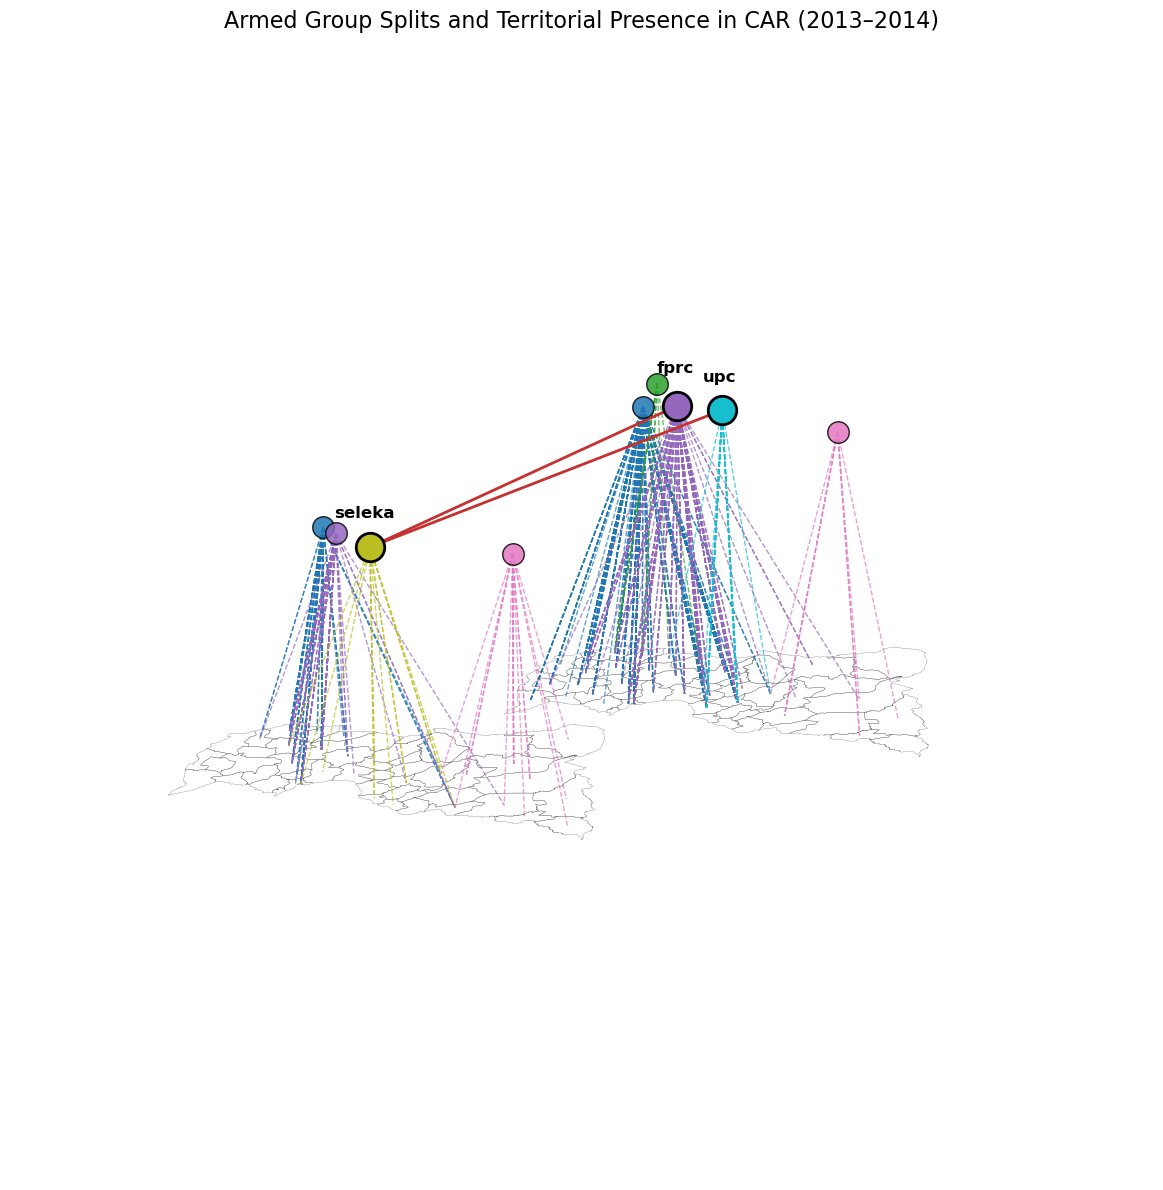

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import affinity
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
dyads = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_parent_child.csv")
actors = pd.read_csv("/Users/samqiu/Desktop/triad_datacollecting-main/car_actors.csv")
gadm = gpd.read_file("/Users/samqiu/Desktop/triad_datacollecting-main/car_adm2.shp")

# ---------------------------------------------------
# CLEAN
# ---------------------------------------------------
for col in ["group_A", "group_B"]:
    dyads[col] = dyads[col].astype(str).str.strip().str.lower()

actors["actor"] = actors["actor"].astype(str).str.strip().str.lower()
actors["NAME_2"] = actors["NAME_2"].astype(str).str.strip().str.lower()
gadm["NAME_2"] = gadm["NAME_2"].astype(str).str.strip().str.lower()

dyads["split_month"] = pd.to_datetime(dyads["split_month"])
dyads["split_year"] = dyads["split_month"].dt.year

actors["st"] = pd.to_datetime(actors["st"])
actors["ed"] = pd.to_datetime(actors["ed"])
actors["start_year"] = actors["st"].dt.year
actors["end_year"] = actors["ed"].dt.year

year_1 = 2013
year_2 = 2014

# ---------------------------------------------------
# ACTIVE ACTORS
# ---------------------------------------------------
def active_actors_year(df, year):
    return df[(df["start_year"] <= year) & (df["end_year"] >= year)].copy()

df13 = active_actors_year(actors, year_1)
df14 = active_actors_year(actors, year_2)

splits_2014 = dyads[(dyads["split"] == 1) & (dyads["split_year"] == year_2)].copy()

# ---------------------------------------------------
# NORMALIZE MAP GEOMETRY
# ---------------------------------------------------
minx, miny, maxx, maxy = gadm.total_bounds

def normalize_geom(geom, target_width=40.0):
    width = maxx - minx
    if width == 0:
        return geom
    scale = target_width / width
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(minx, miny))
    g = affinity.translate(g, xoff=-minx * scale, yoff=-miny * scale)
    return g

gadm = gadm.copy()
gadm["geometry"] = gadm["geometry"].apply(normalize_geom)

# ---------------------------------------------------
# REPROJECT FOR SAFE CENTROID
# ---------------------------------------------------
if gadm.crs is not None and gadm.crs.is_geographic:
    gadm_proj = gadm.to_crs(epsg=3857)
else:
    gadm_proj = gadm.copy()

gadm_proj["centroid"] = gadm_proj.geometry.centroid
gadm["centroid"] = (
    gadm_proj.set_geometry("centroid")
             .to_crs(gadm.crs)["centroid"]
)

# ---------------------------------------------------
# ACTOR POSITIONS (MEAN CENTROID)
# ---------------------------------------------------
def compute_actor_positions(df_year, xoff=0.0, yoff=0.0):
    positions = {}
    for actor in df_year["actor"].unique():
        locs = df_year[df_year["actor"] == actor]["NAME_2"]
        centroids = gadm[gadm["NAME_2"].isin(locs)]["centroid"]
        if len(centroids) == 0:
            continue
        x_mean = centroids.x.mean() + xoff
        y_mean = centroids.y.mean() + yoff
        positions[actor] = (x_mean, y_mean)
    return positions

x_shift = 18.0
y_shift = 18.0

pos13 = compute_actor_positions(df13)
pos14 = compute_actor_positions(df14, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# COLORS
# ---------------------------------------------------
all_groups = sorted(set(list(pos13.keys()) + list(pos14.keys())))
base_colors = plt.cm.tab10(np.linspace(0, 1, len(all_groups)))
actor_colors = {g: base_colors[i] for i, g in enumerate(all_groups)}

# ---------------------------------------------------
# 3D FIGURE
# ---------------------------------------------------
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection="3d")

z_map_2013 = 0.0
z_platform_2013 = 1
z_map_2014 = 0.2
z_platform_2014 = 1.4

# ---------------------------------------------------
# PLOT MAP
# ---------------------------------------------------
def plot_map_layer(gdf, z_level, xoff=0.0, yoff=0.0):
    for geom in gdf.geometry:
        geom2 = affinity.translate(geom, xoff=xoff, yoff=yoff)
        if geom2.geom_type == "Polygon":
            x, y = geom2.exterior.xy
            ax.plot(x, y, np.full_like(x, z_level),
                    color="black", linewidth=0.25, alpha=0.5)
        elif geom2.geom_type == "MultiPolygon":
            for poly in geom2.geoms:
                x, y = poly.exterior.xy
                ax.plot(x, y, np.full_like(x, z_level),
                        color="black", linewidth=0.25, alpha=0.5)

plot_map_layer(gadm, z_map_2013)
plot_map_layer(gadm, z_map_2014, xoff=x_shift, yoff=y_shift)

# ---------------------------------------------------
# PLOT ACTORS (LABEL ONLY THREE)
# ---------------------------------------------------
highlight_2013 = {"seleka"}
highlight_2014 = {"fprc", "upc"}

def radial_offsets(n, radius=0.6):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return [(radius * np.cos(a), radius * np.sin(a)) for a in angles]

# ---------- 2013 ----------
actors_13 = list(pos13.items())
offsets_13 = radial_offsets(len(actors_13))

for ((actor, (x, y)), (dx, dy)) in zip(actors_13, offsets_13):

    is_highlight = actor in highlight_2013

    ax.scatter(
        x, y, z_platform_2013,
        s=420 if is_highlight else 240,
        color=actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    if is_highlight:
        ax.text(
            x + dx,
            y + dy,
            z_platform_2013 + 0.15,
            actor,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )

# ---------- 2014 ----------
actors_14 = list(pos14.items())
offsets_14 = radial_offsets(len(actors_14))

for ((actor, (x, y)), (dx, dy)) in zip(actors_14, offsets_14):

    is_highlight = actor in highlight_2014

    ax.scatter(
        x, y, z_platform_2014,
        s=420 if is_highlight else 240,
        color=actor_colors[actor],
        edgecolor="black",
        linewidth=2 if is_highlight else 1,
        alpha=1.0 if is_highlight else 0.85
    )

    if is_highlight:
        ax.text(
            x + dx,
            y + dy,
            z_platform_2014 + 0.15,
            actor,
            fontsize=12,
            fontweight="bold",
            ha="center",
            va="center"
        )

# ---------------------------------------------------
# ACTOR → EACH LOCATION (DASHED)
# ---------------------------------------------------
def link_actor_to_each_location(df_year, pos_dict,
                                z_platform, z_map,
                                actor_xoff=0.0, actor_yoff=0.0,
                                map_xoff=0.0, map_yoff=0.0):

    for actor in df_year["actor"].unique():
        if actor not in pos_dict:
            continue

        x_actor, y_actor = pos_dict[actor]
        x_actor += actor_xoff
        y_actor += actor_yoff

        locs = df_year[df_year["actor"] == actor]["NAME_2"]

        for loc in locs:
            sub = gadm[gadm["NAME_2"] == loc]
            if sub.empty:
                continue

            centroid = sub["centroid"].iloc[0]
            centroid = affinity.translate(centroid, xoff=map_xoff, yoff=map_yoff)

            ax.plot([x_actor, centroid.x],
                    [y_actor, centroid.y],
                    [z_platform, z_map],
                    color=actor_colors[actor],
                    linewidth=1.0,
                    alpha=0.7,
                    linestyle="dashed")

link_actor_to_each_location(df13, pos13,
                            z_platform_2013, z_map_2013)

link_actor_to_each_location(df14, pos14,
                            z_platform_2014, z_map_2014,
                            map_xoff=x_shift,
                            map_yoff=y_shift)

# ---------------------------------------------------
# SPLIT LINKS
# ---------------------------------------------------
for _, row in splits_2014.iterrows():
    parent = row["group_A"]
    child = row["group_B"]

    if parent in pos13 and child in pos14:
        x1, y1 = pos13[parent]
        x2, y2 = pos14[child]

        ax.plot([x1, x2],
                [y1, y2],
                [z_platform_2013, z_platform_2014],
                color="#c53030", linewidth=2)

# ---------------------------------------------------
# CLEAN VISUAL
# ---------------------------------------------------
ax.set_axis_off()
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.5])

plt.title("Armed Group Splits and Territorial Presence in CAR (2013–2014)",
          fontsize=16)
plt.tight_layout()
plt.savefig(
    "/Users/samqiu/Desktop/triad_datacollecting-main/splits_car_1314.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
